# 03 — Model Extension: comparing candidate model families

This is **Step 2** of the roadmap in `process_visualisation.ipynb` (Diagram B): apply the exact
same setup — same cleaned features, same preprocessing, same cross-validation scheme — to
several candidate model families, compare them on PR-AUC, and see which one earns the right to
be tuned in a future Step 3. No hyperparameter tuning, no feature selection, no resampling here —
same rule as `02_baseline_model.ipynb`'s baseline: cross-validation measures these models
honestly, it doesn't optimize them.

Candidates, alongside the `02_baseline_model.ipynb` logistic regression baseline:

- **Random Forest** — captures non-linear effects/interactions; imbalance handling via
  `class_weight="balanced"`, same lever as the baseline.
- **KNN** — a genuinely different bet: distance-based, no native `class_weight` option at all
  (flagged explicitly below — this is expected to hurt it on a ~5.6%-imbalanced dataset, not a
  bug).
- **XGBoost** — a new dependency for this project (not used in `01`/`02`); imbalance handling
  via `scale_pos_weight`, XGBoost's equivalent of `class_weight`.
- **LightGBM** — added on top of the original four: the actual model family the real 4th-place
  Zindi solution used (`00_project_plan.md` §4.4), with `class_weight="balanced"` like Random
  Forest. Run through the same one-hot-encoded pipeline as everything else here for a fair,
  apples-to-apples comparison -- LightGBM's native categorical handling (no one-hot needed) is a
  real optimization it's *not* getting in this pass, worth trying separately later.
- **Isolation Forest** — unsupervised anomaly detection; fits *without* using `target` at all,
  wrapped in a small adapter so it can run through the identical pipeline/CV machinery as the
  other four (see Step 3). A different bet than the other three, not held to the same bar.

## Imports and constants

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display
from sklearn.base import BaseEstimator, ClassifierMixin
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import IsolationForest, RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import precision_recall_curve
from sklearn.model_selection import StratifiedKFold, cross_val_predict, cross_validate
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from lightgbm import LGBMClassifier
from xgboost import XGBClassifier

pd.set_option("display.max_columns", 100)

DATA_DIR = Path("data")
PROCESSED_DIR = DATA_DIR / "processed"
TRAIN_FEATURES_PATH = PROCESSED_DIR / "train_client_features.csv"

RSEED = 42  # same seed 01_eda.ipynb / 02_baseline_model.ipynb use
N_SPLITS = 5
TOP_K_SHARE = 0.10  # same capacity slice as 02_baseline_model.ipynb, for a direct comparison

# Reference numbers from 02_baseline_model.ipynb -- not re-computed here, just cited.
DUMMY_AVERAGE_PRECISION = 0.056092
DUMMY_ROC_AUC = 0.501831

if not TRAIN_FEATURES_PATH.exists():
    raise FileNotFoundError(
        f"Missing {TRAIN_FEATURES_PATH}. Run 01_eda.ipynb with SAVE_FEATURES = True first "
        "to produce the cleaned, client-level feature table this notebook loads."
    )

## Step 1 — Load the cleaned, client-level features

In [2]:
df = pd.read_csv(TRAIN_FEATURES_PATH)
df["client_id"] = df["client_id"].astype("string")
for column in ["creation_date", "first_invoice", "last_invoice"]:
    df[column] = pd.to_datetime(df[column])
df["target"] = df["target"].astype("int8")
df["has_negative_tenure"] = df["has_negative_tenure"].astype("int8")

overview = pd.DataFrame({
    "rows": [len(df)],
    "unique_clients": [df["client_id"].nunique()],
    "fraud_rate": [df["target"].mean()],
})
display(overview)

,rows,unique_clients,fraud_rate
0,108394,108394,0.055843


## Step 2 — Preprocessing (identical to `02_baseline_model.ipynb`)

Same exclusions, same numeric impute+scale / categorical one-hot split, same `ColumnTransformer`
-- duplicated here (not imported) so this notebook can run on its own, but deliberately
unchanged so every model below is compared on exactly the same footing as the baseline.

In [3]:
exclude_columns = [
    "client_id", "target", "creation_date", "first_invoice", "last_invoice", "invoice_count_group",
]
categorical_features = ["client_catg", "region", "disrict"]
numeric_features = [
    column for column in df.columns
    if column not in exclude_columns and column not in categorical_features
]

X = df[numeric_features + categorical_features]
y = df["target"]

preprocessor = ColumnTransformer([
    ("numeric", Pipeline([
        ("impute", SimpleImputer(strategy="median")),
        ("scale", StandardScaler()),
    ]), numeric_features),
    ("categorical", OneHotEncoder(handle_unknown="ignore"), categorical_features),
])

base_rate = y.mean()
cv = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=RSEED)

## Step 3 — Define the candidate models

`IsolationForestAnomalyScorer` is a small adapter, not a new algorithm: `IsolationForest` fits
without looking at `target` at all (unsupervised) and its native score runs the *opposite*
direction of every other model here (low score = anomaly). The wrapper fits it as usual, then
negates its anomaly score so "higher = more likely fraud" holds for every model in this
notebook — the only way to legitimately drop it into the same `Pipeline`/`cross_validate`/
`cross_val_predict` calls as the four supervised models. The min-max rescale inside
`predict_proba` is cosmetic: every metric used below (PR-AUC, ROC-AUC, precision@k, recall@k) is
rank-based, so it is unaffected by a monotonic rescaling of the score.

`scale_pos_weight` for XGBoost is computed once from the full development set (not refit per
fold) -- a fixed global class-balance constant, not a data-dependent parameter, so this is the
same kind of simplification as `class_weight="balanced"` computing its weights from whichever
labels it's given. LightGBM gets `class_weight="balanced"` directly (it supports the same
sklearn-style argument as Random Forest), so no separate constant is needed for it.

In [4]:
class IsolationForestAnomalyScorer(ClassifierMixin, BaseEstimator):
    """Wraps IsolationForest so it plugs into the same supervised-shaped Pipeline/CV machinery
    as the other models. Fits WITHOUT using the label (unsupervised); predict_proba negates and
    min-max rescales the anomaly score so higher = more anomalous = more likely fraud."""

    def __init__(self, n_estimators=100, contamination="auto", random_state=None):
        self.n_estimators = n_estimators
        self.contamination = contamination
        self.random_state = random_state

    def fit(self, X, y=None):
        self.classes_ = np.array([0, 1])
        self.model_ = IsolationForest(
            n_estimators=self.n_estimators,
            contamination=self.contamination,
            random_state=self.random_state,
        )
        self.model_.fit(X)  # unsupervised -- y is accepted (for Pipeline compatibility) and ignored
        return self

    def predict_proba(self, X):
        raw = -self.model_.score_samples(X)  # flip sign: higher now means more anomalous
        scaled = (raw - raw.min()) / (raw.max() - raw.min() + 1e-12)
        return np.column_stack([1 - scaled, scaled])

    def predict(self, X):
        return (self.predict_proba(X)[:, 1] >= 0.5).astype(int)


scale_pos_weight = (y == 0).sum() / (y == 1).sum()
print(f"XGBoost scale_pos_weight (negatives / positives): {scale_pos_weight:.2f}")

model_specs = {
    "logistic_regression": LogisticRegression(max_iter=1000, class_weight="balanced", random_state=RSEED),
    "random_forest": RandomForestClassifier(class_weight="balanced", random_state=RSEED, n_jobs=-1),
    "knn": KNeighborsClassifier(n_jobs=-1),  # no class_weight option -- see Step 3 markdown
    "xgboost": XGBClassifier(
        scale_pos_weight=scale_pos_weight, eval_metric="logloss", random_state=RSEED, n_jobs=-1
    ),
    "lightgbm": LGBMClassifier(class_weight="balanced", random_state=RSEED, n_jobs=-1, verbosity=-1),
    "isolation_forest": IsolationForestAnomalyScorer(random_state=RSEED),
}

pipelines = {
    name: Pipeline([("preprocess", preprocessor), ("model", model)])
    for name, model in model_specs.items()
}

XGBoost scale_pos_weight (negatives / positives): 16.91


## Step 4 — Cross-validated comparison: PR-AUC and ROC-AUC

In [5]:
comparison_rows = {}
for name, pipeline in pipelines.items():
    cv_results = cross_validate(pipeline, X, y, cv=cv, scoring=["average_precision", "roc_auc"])
    comparison_rows[name] = {
        "average_precision_mean": cv_results["test_average_precision"].mean(),
        "average_precision_std": cv_results["test_average_precision"].std(),
        "roc_auc_mean": cv_results["test_roc_auc"].mean(),
        "roc_auc_std": cv_results["test_roc_auc"].std(),
    }
    print(f"done: {name}")

model_comparison = pd.DataFrame(comparison_rows).T
model_comparison.loc["dummy (from 02, not re-run)"] = {
    "average_precision_mean": DUMMY_AVERAGE_PRECISION, "average_precision_std": np.nan,
    "roc_auc_mean": DUMMY_ROC_AUC, "roc_auc_std": np.nan,
}
model_comparison = model_comparison.sort_values("average_precision_mean", ascending=False)
display(model_comparison)

done: logistic_regression


done: random_forest


done: knn


done: xgboost


done: lightgbm


done: isolation_forest


,average_precision_mean,average_precision_std,roc_auc_mean,roc_auc_std
lightgbm,0.245438,0.009977,0.831780,0.004628
random_forest,0.228652,0.007717,0.815394,0.005609
xgboost,0.228613,0.010785,0.808815,0.006359
logistic_regression,0.173144,0.004364,0.798602,0.004865
knn,0.141347,0.006358,0.683168,0.007060
isolation_forest,0.079446,0.002566,0.570274,0.006134
"dummy (from 02, not re-run)",0.056092,NaN,0.501831,NaN


## Step 5 — Capacity-aware comparison: precision@10% / recall@10%

done: logistic_regression


done: random_forest


done: knn


done: xgboost


done: lightgbm


done: isolation_forest


,precision_at_k,recall_at_k
lightgbm,0.248063,0.444243
random_forest,0.238469,0.427061
xgboost,0.235978,0.422600
logistic_regression,0.207472,0.371551
knn,0.185332,0.331902
isolation_forest,0.094096,0.168511


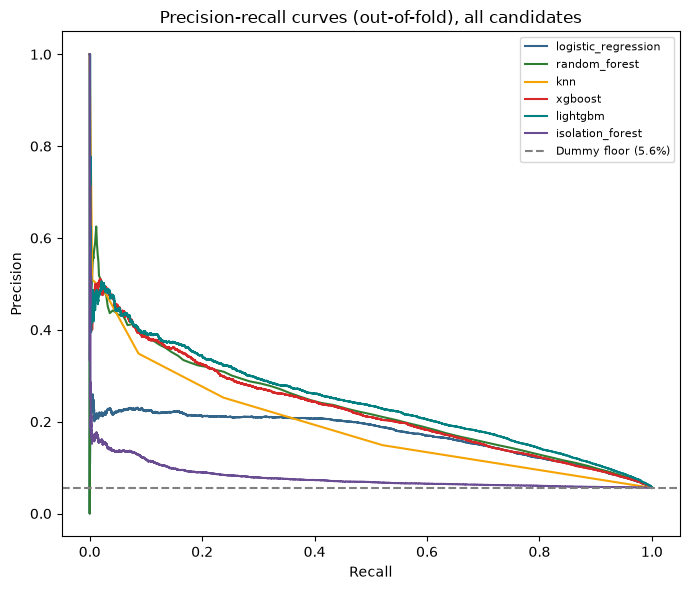

In [6]:
y_values = y.to_numpy()
k = int(np.ceil(TOP_K_SHARE * len(y_values)))

oof_probas = {}
capacity_rows = {}
for name, pipeline in pipelines.items():
    oof_proba = cross_val_predict(pipeline, X, y, cv=cv, method="predict_proba")[:, 1]
    oof_probas[name] = oof_proba

    ranked_order = np.argsort(oof_proba)[::-1]
    top_k_idx = ranked_order[:k]
    precision_at_k = y_values[top_k_idx].mean()
    recall_at_k = y_values[top_k_idx].sum() / y_values.sum()
    capacity_rows[name] = {"precision_at_k": precision_at_k, "recall_at_k": recall_at_k}
    print(f"done: {name}")

capacity_comparison = pd.DataFrame(capacity_rows).T.sort_values("precision_at_k", ascending=False)
display(capacity_comparison)

fig, ax = plt.subplots(figsize=(7, 6))
colors = {"logistic_regression": "#33658A", "random_forest": "#2E7D32", "knn": "#F4A300",
          "xgboost": "#D62828", "lightgbm": "#008080", "isolation_forest": "#6A4C93"}
for name, oof_proba in oof_probas.items():
    precisions, recalls, _ = precision_recall_curve(y_values, oof_proba)
    ax.plot(recalls, precisions, label=name, color=colors.get(name))
ax.axhline(base_rate, linestyle="--", color="grey", label=f"Dummy floor ({base_rate:.1%})")
ax.set(xlabel="Recall", ylabel="Precision", title="Precision-recall curves (out-of-fold), all candidates")
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

## Results

| Model | PR-AUC | ROC-AUC | Precision@10% | Recall@10% |
|---|---|---|---|---|
| **LightGBM** | **0.245** | **0.832** | **24.8%** | **44.4%** |
| Random Forest | 0.229 | 0.815 | 23.8% | 42.7% |
| XGBoost | 0.229 | 0.809 | 23.6% | 42.3% |
| Logistic Regression (`02`) | 0.173 | 0.799 | 20.7% | 37.2% |
| KNN | 0.141 | 0.683 | 18.5% | 33.2% |
| Isolation Forest | 0.079 | 0.570 | 9.4% | 16.9% |
| Dummy (`02`, not re-run) | 0.056 | 0.502 | -- | -- |

## Interpretation

- **LightGBM is the clear leader**, not part of a tie -- PR-AUC 0.245 vs. Random Forest/XGBoost's
  0.229 (a further ~7% relative lift on top of what the tree-ensemble family change already gave
  over logistic regression), and it leads on every single metric reported: PR-AUC, ROC-AUC,
  precision@10%, and recall@10%. The precision-recall curve confirms this isn't a one-point
  artifact -- LightGBM's curve sits visibly above Random Forest/XGBoost's across almost the
  entire recall range, and it gets there **without even using its native categorical handling**
  (it went through the same one-hot-encoded pipeline as everything else, purely for a fair
  comparison in this pass).
- **Random Forest and XGBoost are now the tied *second* tier**, not co-leaders -- both still
  clearly ahead of logistic regression, but no longer the headline result.
- **KNN and Isolation Forest read the same as before**: KNN underperforms even the linear
  baseline (no `class_weight` lever), and Isolation Forest is the weakest model but still clearly
  above the dummy floor -- a modest, label-free anomaly signal worth a mention, not a serious
  candidate.
- This matches the evidence cited going in: the real 4th-place Zindi solution used LightGBM, and
  it's now the leader here too, on a fraction of that solution's feature engineering.

### Next steps

- **Tune LightGBM** -- it's now the clear single winner, not a tie needing two tuning runs.
  `GridSearchCV`/`RandomizedSearchCV` (or Optuna, as the real 4th-place solution used) against
  PR-AUC, same CV scheme.
- **Try LightGBM's native categorical handling** (pass `region`/`disrict`/`client_catg` as
  categorical dtype instead of one-hot) as a cheap follow-up variant, now that it's the model
  worth spending extra attention on.
- **Random Forest and XGBoost drop to "worth keeping as a reference," not tuning targets** --
  tuning them is unlikely to close a 7% relative gap to an already-stronger, untuned model.
- **Retire KNN and Isolation Forest as primary candidates**, as before.
- **Error analysis next, before tuning** -- see the discussion with Sean and Roy on sequencing:
  cheap to do (reuses the out-of-fold predictions already computed above), and its findings
  (systematic misses, segment weaknesses, whether models' errors overlap) should inform *what*
  gets tuned and whether an ensemble is worth trying, rather than tuning blind.
- **Feature optimization / imbalance gates are still not triggered** -- no evidence yet that
  Lasso/PCA or SMOTE would beat what the family change to LightGBM already delivered.